## Some example plots using trajectories from opendrift_example.py

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import functions as f
import datetime as dt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cmocean as cm

## Extract temp and salinity along trajectory
### Note: Cartopy landmask is too low resolution for Norwegian fjords, thus particles may seem to traverse through land in the following plots. 

In [10]:
traj_file = 'sample_file.nc'
model_file = 'https://thredds.met.no/thredds/dodsC/fou-hi/norkystv3_160m_m70_be'
pos = xr.open_dataset(traj_file)
temps = f.model_variables_along_trajectory(traj=traj_file, model=model_file, variable='temperature')
sal = f.model_variables_along_trajectory(traj=traj_file, model=model_file, variable='salinity')

Text(0.5, 0.98, 'NK160 particle trajectories\nSulafjorden 2024-06-12T12:00:00 - 2024-06-22T22:00:00')

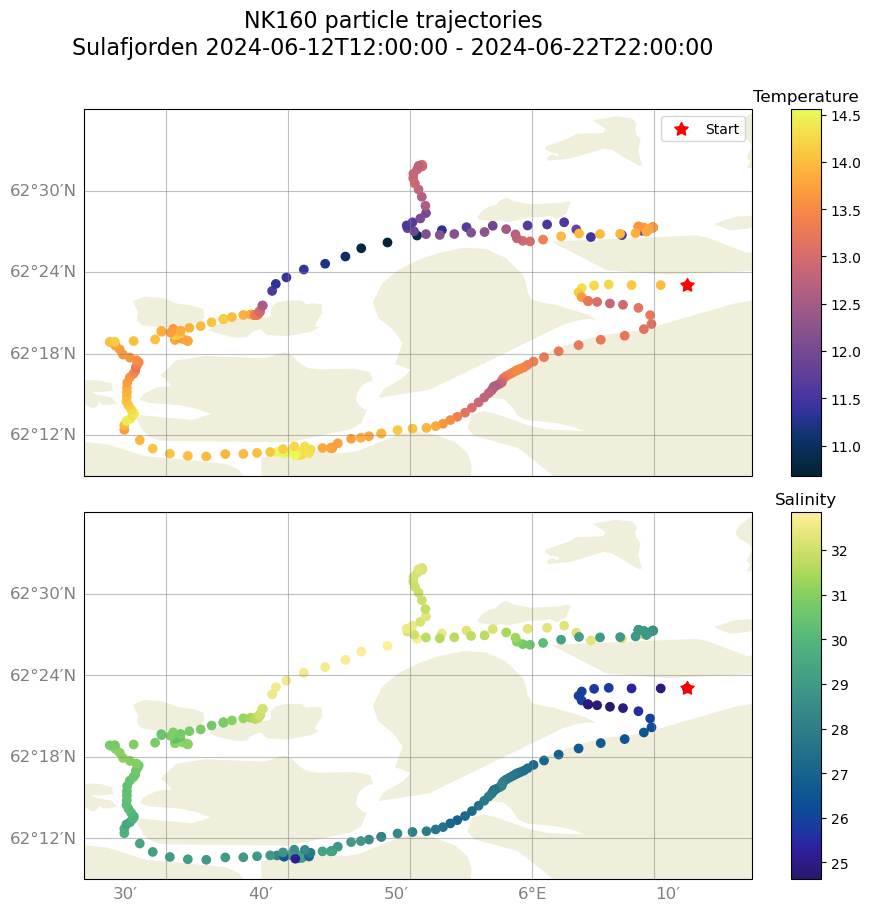

In [11]:
label_style = {'size': 12, 'color': 'gray'}

fig, ax = plt.subplots(2, figsize=(20,10), subplot_kw={'projection':ccrs.PlateCarree()})
plt.subplots_adjust(hspace=0.1)
im = ax[0].scatter(pos.lon, pos.lat, c=temps, cmap=cm.cm.thermal, transform=ccrs.PlateCarree(), zorder=1)
cax = fig.add_axes([ax[0].get_position().x1+0.005, ax[0].get_position().y0, 0.015, ax[0].get_position().height])
cbar = fig.colorbar(im, ax=ax[0], cax=cax)
cbar.ax.set_title('Temperature')
im2 = ax[1].scatter(pos.lon, pos.lat, c=sal, cmap=cm.cm.haline, transform=ccrs.PlateCarree(), zorder=1)
cax = fig.add_axes([ax[1].get_position().x1+0.005, ax[1].get_position().y0, 0.015, ax[1].get_position().height])
cbar = fig.colorbar(im2, ax=ax[1], cax=cax)
cbar.ax.set_title('Salinity')
for i in range(2):
    ax[i].scatter(pos.lon.isel(time=0), pos.lat.isel(time=0), marker=(5,1), c='Red', s=100, label='Start', zorder=2)
    gl = ax[i].gridlines(crs=ccrs.PlateCarree(), color='black', draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=200)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = label_style
    gl.ylabel_style = label_style
    gl.rotate_labels = False
    gl.xlines = gl.ylines = None
    if i == 0:
        gl.bottom_labels=False
    ax[i].gridlines(crs=ccrs.PlateCarree(), color='grey', draw_labels=False, x_inline=False, y_inline=False, zorder=0, alpha=0.5)
    ax[i].add_feature(cartopy.feature.LAND)
    ax[i].set_extent([5.45, 6.27, 62.6, 62.15])
ax[0].legend()
fig.suptitle(f'NK160 particle trajectories\nSulafjorden {str(pos.time.values[0])[:-10]} - {str(pos.time.values[-1])[:-10]}', fontsize=16)

## Overview map

Text(0.5, 0.98, 'NK160 particle trajectories\nSulafjorden 2024-06-12T12:00:00 - 2024-06-22T22:00:00')

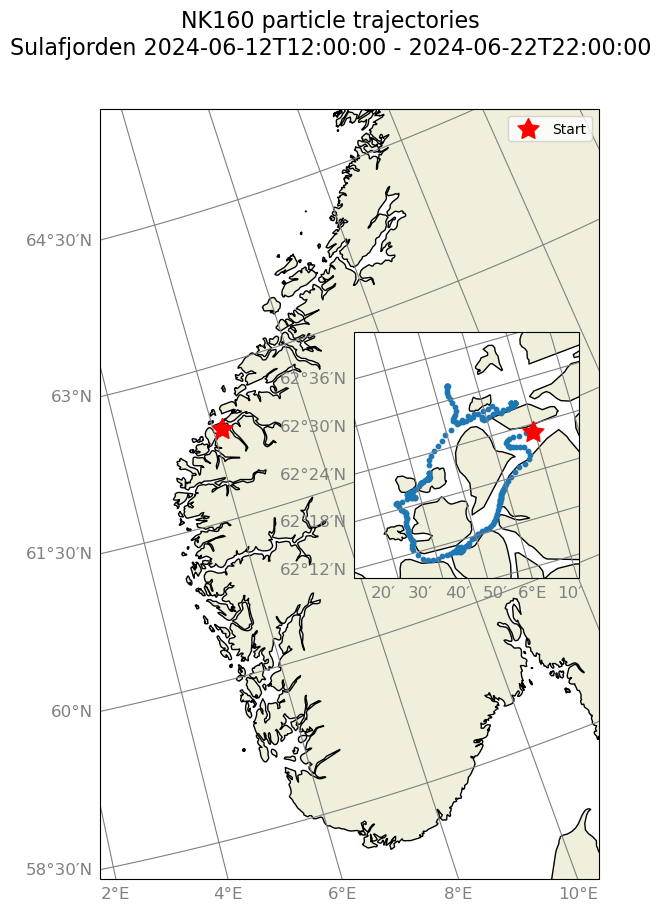

In [12]:
pos = xr.open_dataset(traj_file)
fig = plt.figure(figsize=(15,10))
proj = ccrs.NorthPolarStereo(central_longitude=-10)
spec = fig.add_gridspec(nrows=10, ncols=20)
ax0 = fig.add_subplot(spec[0:10, 0:20], projection=proj)
ax0.set_extent([5,11,58,65], ccrs.PlateCarree())
ax0.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')

ax0.scatter(pos.lon.isel(time=0), pos.lat.isel(time=0), transform=ccrs.PlateCarree(), marker=(5,1), c='Red', s=250, label='Start')

ax1 = fig.add_subplot(spec[2:7, 10:14], projection=proj)
#gdf.plot(ax=ax1, color='beige', zorder=0)
ax1.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='black')
ax1.scatter(pos.lon.isel(time=0), pos.lat.isel(time=0), transform=ccrs.PlateCarree(), marker=(5,1), c='Red', s=250, zorder=3)
ax1.scatter(pos.lon, pos.lat, transform=ccrs.PlateCarree(), zorder=2, s=10)
ax1.set_extent([5.45, 6.27, 62.6, 62.15])
ax0.legend()

subax = [ax0, ax1]
for ax in subax:
    gl = ax.gridlines(crs=ccrs.PlateCarree(), color='black', draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=200)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = label_style
    gl.ylabel_style = label_style
    gl.rotate_labels = False
    gl.xlines = gl.ylines = None
    ax.gridlines(crs=ccrs.PlateCarree(), color='grey', draw_labels=False, x_inline=False, y_inline=False, zorder=0)
fig.suptitle(f'NK160 particle trajectories\nSulafjorden {str(pos.time.values[0])[:-10]} - {str(pos.time.values[-1])[:-10]}', fontsize=16)

## Extract temperature along a trajectory for a constant time

In [13]:
temps = f.model_variables_along_trajectory(traj=traj_file, variable='temperature', model=model_file, constant_time=dt.datetime(2024,6,11,12))
temps2 = f.model_variables_along_trajectory(traj=traj_file, variable='temperature', model=model_file, constant_time=dt.datetime(2024,12,11,12))

Text(0.5, 1.0, 'Temperature along trajectory\n2024-12-11T12:00:00')

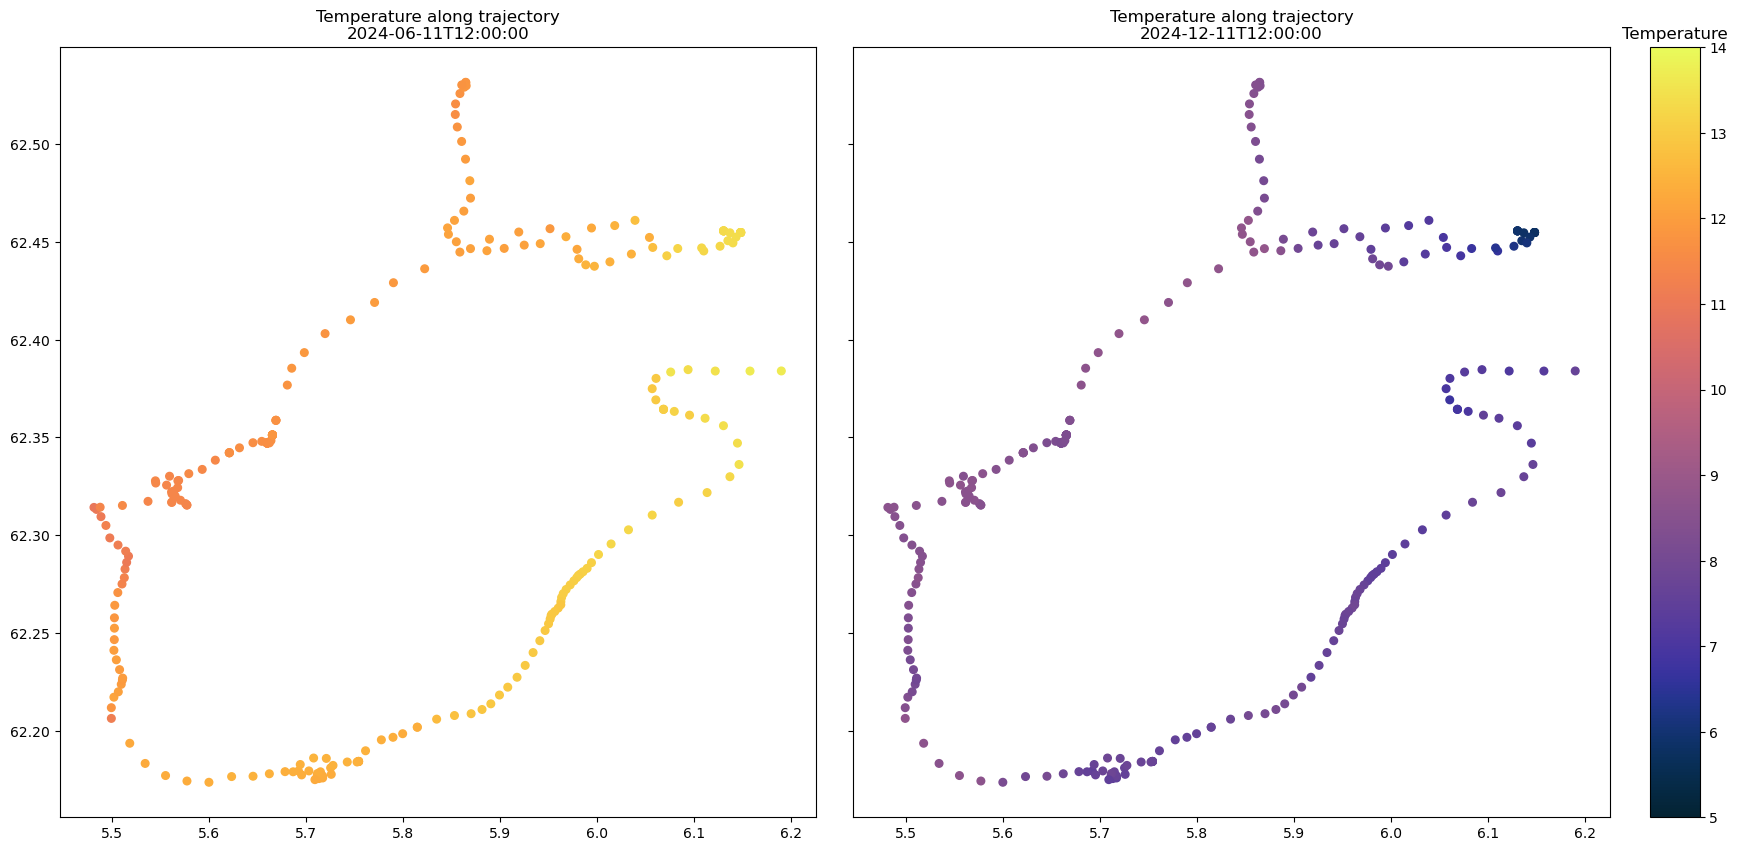

In [14]:
fig, ax = plt.subplots(1,2, figsize=(20,10), sharey=True)
im = ax[0].scatter(pos.lon, pos.lat, s=30, c=temps, vmin=5, vmax=14, cmap=cm.cm.thermal)
im2 = ax[1].scatter(pos.lon, pos.lat, s=30, c=temps2, vmin=5, vmax=14, cmap=cm.cm.thermal)
plt.subplots_adjust(wspace=0.05)
cax = fig.add_axes([ax[1].get_position().x1+0.02, ax[1].get_position().y0, 0.025, ax[1].get_position().height])
cbar = fig.colorbar(im, ax=ax[1], cax=cax)
cbar.ax.set_title('Temperature')
ax[0].set_title('Temperature along trajectory\n2024-06-11T12:00:00')
ax[1].set_title('Temperature along trajectory\n2024-12-11T12:00:00')

## Extract temperature along a trajectory for a specified time range

In [15]:
datelist = pd.date_range(dt.datetime(2024,11,11,12), periods=251, freq='1h').to_pydatetime().tolist()
temps = f.model_variables_along_trajectory(traj=traj_file, model=model_file, variable='temperature', times=datelist)

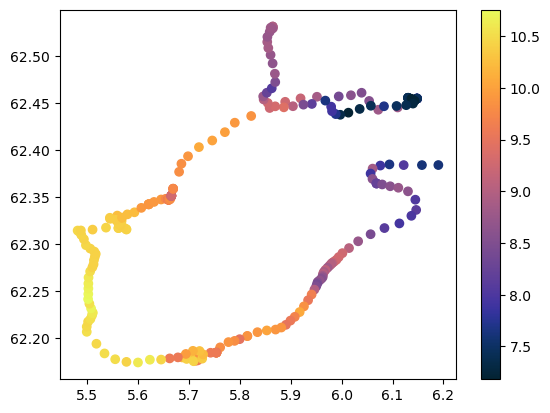

In [16]:
im = plt.scatter(pos.lon, pos.lat, c=temps, cmap=cm.cm.thermal) 
plt.colorbar()

## Evolution of temp over the defined time range

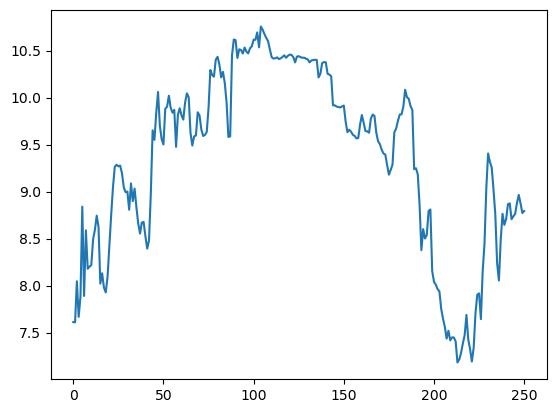

In [17]:
x = np.linspace(0, len(temps)-1, len(temps))
plt.plot(x, temps)